<h1><font color = 'red'> <center>GIS Apps in Engineering: Assignment 5</h1>
<h3><font color = 'blue'> <center>Lajuk</h3>

### Problem Statement


1. Take lat-long for El Paso, San Antonio, Austin, Dallas, Houston and Beaumont in a CSV
file and create a pandas Geodataframe using the Shapely Point Object.

2. Create two line strings - 1) Line Connecting El Paso, San Antonio, Houston and
Beaumont (This is approximately I-10) 2) Create a line connecting Austin and San
Antonio (this is I-35 approiximately)


3. Use the linestrings to create a line geodataframe

   
4. Create a Polygon connecting San Antonio, Austin, Dallas, Houston (use San Antonio to
close the loop). This is the Texas Triangle Create a Geopandas Geodataframe


5. Compute the area of the Texas Triangle in sq. miles


6. Compute Approximately the number of People who live within the Texas Triangle.

In [23]:
#Import Libraries
import geopandas as gpd
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from shapely.geometry import Point, LineString, Polygon
import os
from matplotlib_map_utils.core.north_arrow import north_arrow

In [24]:
#Create a dictionary of city data

data = {
    "City": ["El Paso", "San Antonio", "Austin", "Dallas", "Fort Worth", "Houston", "Beaumont"],
    "Latitude": [31.7619, 29.4241, 30.2672, 32.7767, 32.7555, 29.7604, 30.0802],
    "Longitude": [-106.4850, -98.4936, -97.7431, -96.7970, -97.3308, -95.3698, -94.1266]
}

#Convert dictionary to DataFrame
df = pd.DataFrame(data)

#Save to CSV file
df.to_csv("TXcities.csv", index=False)

print("✅ CSV file 'TXcities.csv' created successfully!")
print(df)


✅ CSV file 'TXcities.csv' created successfully!
          City  Latitude  Longitude
0      El Paso   31.7619  -106.4850
1  San Antonio   29.4241   -98.4936
2       Austin   30.2672   -97.7431
3       Dallas   32.7767   -96.7970
4   Fort Worth   32.7555   -97.3308
5      Houston   29.7604   -95.3698
6     Beaumont   30.0802   -94.1266


In [25]:
path = "/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-5/"
os.chdir(path)
fname = "TXcities.csv"

In [26]:
a=pd.read_csv(fname)
a.head()

,City,Latitude,Longitude
0,El Paso,31.7619,-106.4850
1,San Antonio,29.4241,-98.4936
2,Austin,30.2672,-97.7431
3,Dallas,32.7767,-96.7970
4,Fort Worth,32.7555,-97.3308


In [27]:
# Convert to a dictionary
# The zip() function is used to combine multiple columns (City, Longitude, Latitude)
# dict() converts the zipped object into a dictionary where each city is a key
# and its (Longitude, Latitude) pair is the value
TXcities = dict(zip(a['City'], zip(a['Longitude'], a['Latitude'])))
TXcities

{'El Paso': (-106.485, 31.7619),
 'San Antonio': (-98.4936, 29.4241),
 'Austin': (-97.7431, 30.2672),
 'Dallas': (-96.797, 32.7767),
 'Fort Worth': (-97.3308, 32.7555),
 'Houston': (-95.3698, 29.7604),
 'Beaumont': (-94.1266, 30.0802)}

In [28]:
# Use the Point object of Shapely to create a set of Points
# Iterate over the dictionary to obtain the lon-lat
geom = [Point(coord) for coord in TXcities.values()]
geom

[<POINT (-106.485 31.762)>,
 <POINT (-98.494 29.424)>,
 <POINT (-97.743 30.267)>,
 <POINT (-96.797 32.777)>,
 <POINT (-97.331 32.756)>,
 <POINT (-95.37 29.76)>,
 <POINT (-94.127 30.08)>]

In [29]:
# Create a Geopandas Data Frame
TXcitiesgpd = gpd.GeoDataFrame({"City":list(TXcities.keys())},geometry=geom,crs='EPSG:4326')
TXcitiesgpd.head()

,City,geometry
0,El Paso,POINT (-106.485 31.7619)
1,San Antonio,POINT (-98.4936 29.4241)
2,Austin,POINT (-97.7431 30.2672)
3,Dallas,POINT (-96.797 32.7767)
4,Fort Worth,POINT (-97.3308 32.7555)


<Axes: >

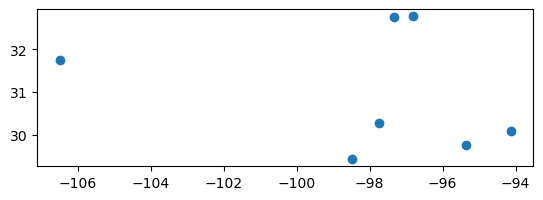

In [30]:
TXcitiesgpd.plot()

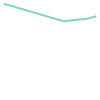

In [31]:
#Create LineSrings for Approx I10 and approx I35
roadI10 = LineString([TXcities['El Paso'],TXcities['San Antonio'],TXcities['Houston'],TXcities['Beaumont']])
roadI10

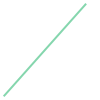

In [32]:
# I-35 roughly connects San Antonio → Austin → Dallas
roadI35 = LineString([TXcities['Austin'],TXcities['San Antonio']])
roadI35

In [33]:
# Create a GeoDataFrame for the approximate highway routes
roads = gpd.GeoDataFrame({"HWY":["I10Approx","I35ApproxASA"]}, geometry= [roadI10,roadI35],crs='EPSG:4326')
roads.head()

,HWY,geometry
0,I10Approx,"LINESTRING (-106.485 31.7619, -98.4936 29.4241..."
1,I35ApproxASA,"LINESTRING (-97.7431 30.2672, -98.4936 29.4241)"


<function matplotlib.pyplot.show(close=None, block=None)>

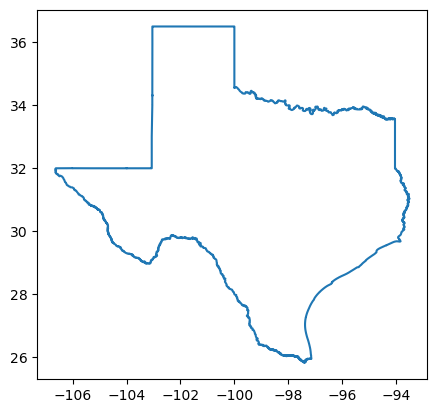

In [34]:
txdis = gpd.read_file("TX_dissolved.gpkg")
txgcs = txdis.to_crs(epsg=4326)
txdiss = txgcs.dissolve()
txext = txdiss.geometry.exterior
txext.plot()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

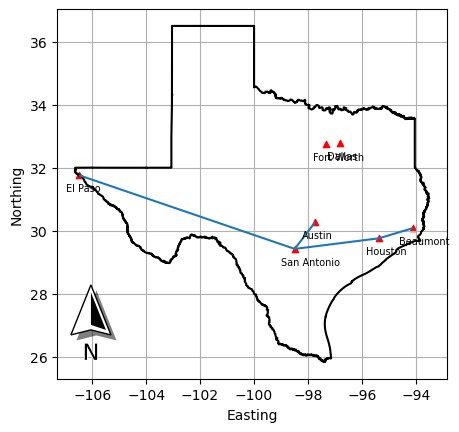

In [35]:
ax = txext.plot(edgecolor = 'black', facecolor = 'none')
roads.plot(ax=ax)
TXcitiesgpd.plot(ax=ax,marker = '^',color='red', markersize=20)
for x, y, label in zip(TXcitiesgpd.geometry.x, TXcitiesgpd.geometry.y, TXcitiesgpd['City']):
    ax.text(x - 0.5, y - 0.5, label, fontsize=7, color='black')
north_arrow(ax=ax, location="lower left", scale=0.5,rotation={"degrees":0})
plt.grid()
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.show

In [36]:
print(os.getcwd())

/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-5


<h4> Create the Texas Triangle Polygon

In [37]:
Txtriangle = Polygon([TXcities['San Antonio'], TXcities['Austin'],
                      TXcities['Fort Worth'], TXcities['Dallas'],
                      TXcities['Houston'], TXcities['San Antonio']])


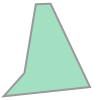

In [38]:
Txtriangle

In [41]:
# For Polygon we need a list for all z
zz = {'Name': ['WonkyT']}
Txtrianglegpd = gpd.GeoDataFrame(zz, geometry=[Txtriangle], crs='EPSG:4326')

# Project to Texas Central projection for accurate area
Txtaea = Txtrianglegpd.to_crs('epsg:5070')

<function matplotlib.pyplot.show(close=None, block=None)>

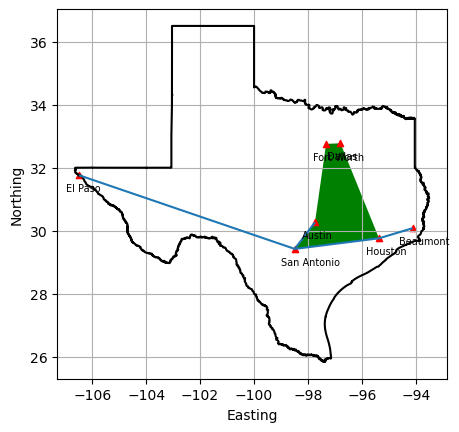

In [42]:
ax = txext.plot(edgecolor = 'black', facecolor = 'none')
roads.plot(ax=ax)
Txtrianglegpd.plot (ax = ax, color ='green')
TXcitiesgpd.plot(ax=ax,marker = '^',color='red', markersize=20)
for x, y, label in zip(TXcitiesgpd.geometry.x, TXcitiesgpd.geometry.y, TXcitiesgpd['City']):
    ax.text(x - 0.5, y - 0.5, label, fontsize=7, color='black')
plt.grid()
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.show

In [43]:
Txtaea['Area'] = Txtaea.area*3.861E-07
# Save to GeoPackage
Txtaea.to_file("TextAea.gpkg", driver="GPKG")
Txtaea.head()

,Name,geometry,Area
0,WonkyT,"POLYGON ((-241987.621 708683.387, -167450.919 ...",20815.103838


In [44]:
# Fraction of Texas covered by the Triangle
TxFracA = Txtaea['Area'].iloc[0] / 268596
print(f"Fraction of Texas area = {TxFracA:.3f}")

# Optional: as a percentage
print(f"≈ {TxFracA * 100:.2f}% of the state area")

Fraction of Texas area = 0.077
≈ 7.75% of the state area


<h3> Estimate the Population in the Texas Triangle

In [52]:
# Read the file containing Population of all Texas Counties
# Got this file using join by attributes of CSV and TXCounty File
TXPOP = gpd.read_file('TxTotal.gpkg')
TXPOP.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,FIPS,county,census_2020_count,july1_2023_pop_est,jan1_2024_pop_est,num_chg_20_23,num_chg_20_24,pct_chg_20_23,pct_chg_20_24,FIPS NEW,geometry
0,232,232,48463,232,15,Uvalde,232,15,35,463,Uvalde,24564,24758,24827,194,263,0.8,1.1,48463,"MULTIPOLYGON (((-11076323.621 3386738.492, -11..."
1,143,143,48285,143,13,Lavaca,143,13,36,285,Lavaca,20337,20274,20113,-63,-224,-0.3,-1.1,48285,"MULTIPOLYGON (((-10783021.183 3456095.21, -107..."
2,20,20,48039,20,12,Brazoria,20,12,37,39,Brazoria,372031,394817,398361,22786,26330,6.1,7.1,48039,"MULTIPOLYGON (((-10606980.495 3451945.262, -10..."
3,241,241,48481,241,13,Wharton,241,13,38,481,Wharton,41570,41700,41711,130,141,0.3,0.3,48481,"MULTIPOLYGON (((-10706181.772 3456563.942, -10..."
4,163,163,48325,163,15,Medina,163,15,39,325,Medina,50748,54889,56338,4141,5590,8.2,11,48325,"MULTIPOLYGON (((-11066621.012 3397753.016, -11..."


In [53]:
print(TXPOP.shape)

(254, 20)


In [54]:
# Calculate the total population
Totpop = np.sum(pd.to_numeric(TXPOP.jan1_2024_pop_est	))
Totpop

np.int64(30749924)

In [57]:
# Read the file containing the Population of Triangle Counties
# You get this file using Join By Location of step above and your Triangle Area
Txfile = gpd.read_file('TXAEAPOP.gpkg')

In [58]:
Txfile.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,FIPS,...,jan1_2024_pop_est,num_chg_20_23,num_chg_20_24,pct_chg_20_23,pct_chg_20_24,FIPS NEW,fid_2,Name,Area,geometry
0,143,143,48285,143,13,Lavaca,143,13,36,285,...,20113,-63,-224,-0.3,-1.1,48285,1,WonkyT,20815.103838,"MULTIPOLYGON (((-10783021.183 3456095.21, -107..."
1,45,45,48089,45,13,Colorado,45,13,46,89,...,21519,685,962,3.3,4.7,48089,1,WonkyT,20815.103838,"MULTIPOLYGON (((-10740733.126 3486568.725, -10..."
2,79,79,48157,80,12,Fort Bend,80,12,43,157,...,911893,75735,89114,9.2,10.8,48157,1,WonkyT,20815.103838,"MULTIPOLYGON (((-10662623.558 3473377.791, -10..."
3,101,101,48201,102,12,Harris,102,12,54,201,...,4848956,106016,117811,2.2,2.5,48201,1,WonkyT,20815.103838,"MULTIPOLYGON (((-10580244.889 3507006.162, -10..."
4,8,8,48015,8,13,Austin,8,13,52,15,...,32309,1707,2142,5.7,7.1,48015,1,WonkyT,20815.103838,"MULTIPOLYGON (((-10702848.867 3512350.878, -10..."


In [65]:
# Read the file containing the Population of Triangle Counties
# You get this file using Join By Location pf Step above and Your Triangle Area
Trianglepop = np.sum(pd.to_numeric(Txfile.jan1_2024_pop_est))
Trianglepop

np.int64(18386124)

In [66]:
# Population Fraction as Percent
PopFrac = 100*Trianglepop/Totpop
print(f"{PopFrac:.2f}%")

59.79%
